IMPORTS

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split

## QUESTION 1 - PYTHON BASICS (10 pts)
### Grading
- Python is dynamic (1 point)
- Python is strongly types (1 point)
- dynamic vs. static explanation (1.5 points)
- strong vs weak explanation (1.5 points)

a) Dynamic vs static refers to when type checking occurs. In statically typed languages (like C++ or Java), variable types are declared and checked at compile-time. In dynamically typed languages (like Python), types are checked at runtime, and a variable can change its type based on the data assigned to it.

b) Strong vs weakly refers to how strictly types are enforced during operations. In strongly typed languages (like Python), implicit type conversion is strictly limited (e.g., trying to add an integer 5 and a string "5" will throw an error). In weakly typed languages (like JavaScript), the language will implicitly coerce the types to make the operation work (e.g., 5 + "5" becomes "55").

### Grading
- mutable vs immutable explanation (3 points)
- mutable example (1 point)
- immutable example (1 point)

b) A mutable object can have its internal state or contents changed in memory after it has been created. An immutable object cannot be changed once it is created; any modification creates a completely new object in memory.

Mutable: Lists (e.g., [1, 2, 3]), Dictionaries, Sets.

Immutable: Tuples (e.g., (1, 2, 3)), Strings, Integers.

## QUESTION 2 - DATA CLEANING WITH PANDAS (30 pts)
a)

- Load dataset: 1 point
- General overview: 1 point
- Dimensions: 1 point
- Column names: 1 point
- First 5 rows: 1 point

b)

Print number of missing values in each column: 5 point
- If you brute force for each column: -2 points
- isna().count(): -3

c)

- Drop rowid and year: 2 points
- Remove two rows where body mass and flipper length are missing: 2 points
- Group dataset according to sex + print mean body mass for each. 3 points
- Impute the remaining values: 3 points

Print missing values again.

d) Remove duplicates and print final shape: 5 points
- If you brute force the removing duplicates: -2 points
- Not assigning correctly: -1

e) Handling missing values verbal answer. When should we drop vs impute?


In [3]:
df = pd.read_csv("penguins.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 346 entries, 0 to 345
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              346 non-null    int64  
 1   species            346 non-null    str    
 2   island             346 non-null    str    
 3   bill_length_mm     344 non-null    float64
 4   bill_depth_mm      344 non-null    float64
 5   flipper_length_mm  344 non-null    float64
 6   body_mass_g        344 non-null    float64
 7   sex                335 non-null    str    
 8   year               346 non-null    int64  
dtypes: float64(4), int64(2), str(3)
memory usage: 24.5 KB


In [4]:
df.shape

(346, 9)

In [5]:
df.columns

Index(['rowid', 'species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex', 'year'],
      dtype='str')

In [6]:
df.head()

,rowid,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [7]:
df.isnull().sum()

rowid                 0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

In [8]:
# 1. Drop rowid and year columns
df.drop(columns=['rowid', 'year'], inplace=True, errors='ignore')

In [9]:
# 2. Remove rows where body_mass and flipper_length are missing
df.dropna(subset=['body_mass_g', 'flipper_length_mm'], inplace=True)

In [10]:
print(df.groupby(by="sex",as_index=False).agg({'body_mass_g':"mean"}))

      sex  body_mass_g
0  female  3861.897590
1    male  4546.449704


In [10]:
mean_mass_by_sex = df.groupby('sex')['body_mass_g'].mean()
print("Mean body mass by sex:\n", mean_mass_by_sex)

Mean body mass by sex:
 sex
female    3861.897590
male      4546.449704
Name: body_mass_g, dtype: float64


In [11]:
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

In [12]:
print("\nMissing values after handling:\n", df.isna().sum())


Missing values after handling:
 species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [13]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

Verbal Answer: Approaches to missing value handling (5 pts)

Dropping Rows/Columns: You should choose to drop rows if the percentage of missing data is very small (e.g., < 5%) and dropping them will not introduce bias into your dataset. You should drop an entire column if a massive majority of its data is missing and it provides little to no predictive value.

Imputing: You should choose to impute (fill in) missing values when you cannot afford to lose the remaining data in those rows.

For numerical data, imputing with the median is preferred if the data is skewed by outliers, while the mean is acceptable for normally distributed data.

For categorical data, imputing with the mode (most frequent value) or adding an "Unknown" category is standard practice. More advanced techniques involve using machine learning to predict the missing values based on other features.

## QUESTION 3 - VISUALIZATION AND INTERPRETATION (30 pts)

a) histogram (5 pts) - no x,y labels -1

b) distribution, skewness, central tendency comment (5 pts)
- right-skewed missing -1

c) Countplot penguins belonging to each species (5 pts)

d) Frequent datasets (5 pts)

e) commenting the scatter plot (10 pts)
- positive correlation between the two features (2 pts) + linear (1 point)
- Gentoo are larger than the rest (2)
- Adelie and Chinstrap overlap, but Adelie tend to be smaller overall (3)
- There are some outliers in Adelie and also others where the body mass is significantly large but the flipper length stays relatively small. (2)

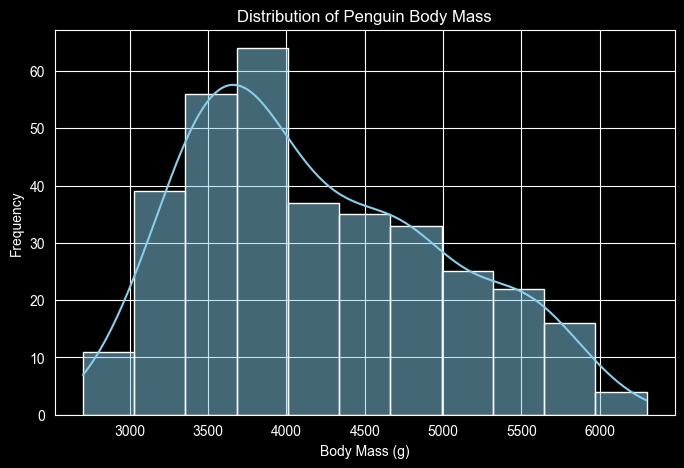

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='body_mass_g', kde=True, color='skyblue')
plt.title('Distribution of Penguin Body Mass')
plt.xlabel('Body Mass (g)')
plt.ylabel('Frequency')
plt.show()

Verbal Answer (e.g., for body mass): "The distribution of body mass is somewhat bimodal (two peaks) and slightly right-skewed. The majority of penguins weigh between 3500g and 4500g, with a secondary peak around 5000g."

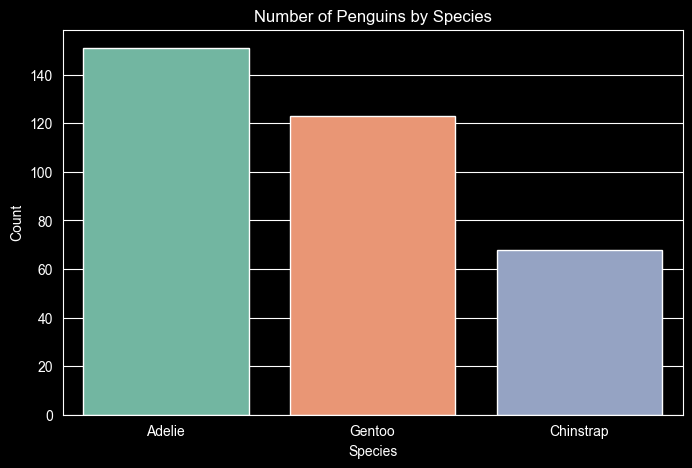

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='species', hue='species', palette='Set2')

plt.title('Number of Penguins by Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

Adelie penguins are the most frequent and the Chinstrap are the least frequent species in the dataset.

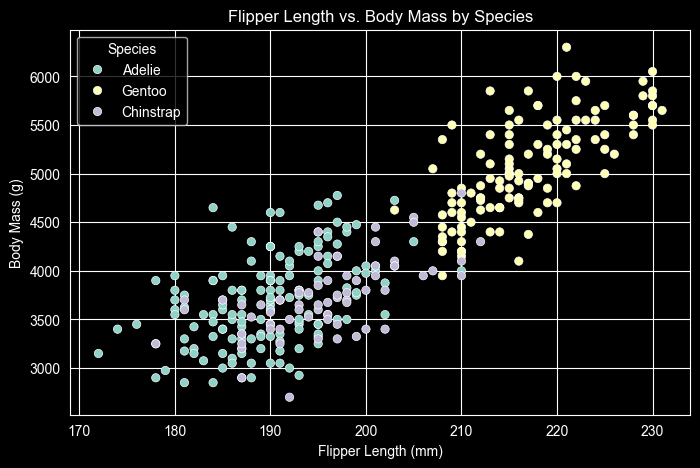

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Flipper Length vs. Body Mass by Species')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.legend(title='Species')
plt.show()

## QUESTION 4 - SPLITTING THE DATASET (30 pts)


Encoding: The island and sex columns are categorical text data. Machine learning models require numbers, so these must be encoded (e.g., using One-Hot Encoding/Dummy Variables).

Scaling/Normalization: The numerical columns (bill_length_mm, body_mass_g, etc.) operate on vastly different scales (millimeters vs. thousands of grams). They need to be normalized or standardized so distance-based models don't overweight body_mass_g simply because the numbers are larger.

a. Verbal Answer:
- categorical text data should be encoded. (4 pts) + examples 1 pt
- numerical values should be scaled/normalized (4 pts) + examples 1 pt

b. Features matrix vs. target Vector (10 pts)

c. train test split (10 pts)

In [18]:
# y is the target species
y = df['species']

# X is everything EXCEPT the target
X = df.drop(columns=['species'])

# Print shapes to verify (X should be 2D, y should be 1D)
print("X shape:", X.shape) # e.g., (333, 6)
print("y shape:", y.shape) # e.g., (333,)

X shape: (342, 6)
y shape: (342,)


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42 # Must include this!
)

# Optional but good practice for students to show
print(X_train.shape, X_test.shape)

(273, 6) (69, 6)


In [20]:
y_test.shape

(69,)

In [21]:
y_train.shape

(273,)